In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

In [ ]:
def stress_invariants(sigm):
    """
    Returns first invariant J1, second invariant J2D, and Lode angle theta (MC)
    """
    J1 = sigm[0] + sigm[1] + sigm[2]

    p = J1 / 3.0
    I = np.array([1., 1., 1., 0., 0., 0.])
    s = sigm - p * I     #shear/deviatoric

    J2D = (0.5 * (s[0]**2 + s[1]**2 + s[2]**2)
           + s[3]**2 + s[4]**2 + s[5]**2)

    # Lode angle from J3D
    if J2D < 1e-12:
        theta = 0.0
    else:
        J3D = (s[0]*s[1]*s[2]
               - s[0]*s[5]**2
               - s[1]*s[4]**2
               - s[2]*s[3]**2
               + 2*s[3]*s[4]*s[5])
        sin3theta = np.clip(-3*np.sqrt(3)/2 * J3D / (J2D**1.5), -1., 1.)
        theta     = 1./3. * np.arcsin(sin3theta)

    return J1, J2D, theta

In [16]:
def C_elastic(K, G):
    """
    6x6 isotropic elastic stiffness matrix
    K, G (kPa)
    """
    t1 = K + 4./3.*G
    t2 = K - 2./3.*G
    t3 = 2.*G

    Cel = np.array([
        [t1, t2, t2,  0,  0,  0],
        [t2, t1, t2,  0,  0,  0],
        [t2, t2, t1,  0,  0,  0],
        [ 0,  0,  0, t3,  0,  0],
        [ 0,  0,  0,  0, t3,  0],
        [ 0,  0,  0,  0,  0, t3]], dtype=float)

    return Cel

In [17]:
def yield_surface_MC(sigm, phi, c):
    """
    Mohr-Coulomb yield surface
    phi : friction angle (radians)
    c   : cohesion (kPa)

    Returns:
        f < 0 : elastic (inside YS)
        f = 0 : on YS
        f > 0 : not possible (outside YS)
    """
    J1, J2D, theta = stress_invariants(sigm)

    f = (-1./3. * J1 * np.sin(phi)
         + np.sqrt(J2D) * (np.cos(theta)
         + 1./np.sqrt(3.) * np.sin(theta) * np.sin(phi))
         - c * np.cos(phi))

    return f

In [ ]:
def crosspoint(sigm, dsigm, phi, c):
    """
    Find crosspoint - beta is portion of step to reach YS
    brentq (equivalent to MATLAB fzero) 
    """
    def f(beta):
        stress_at_beta = sigm + beta * dsigm
        return yield_surface_MC(stress_at_beta, phi, c)

    f0 = f(0.0)
    f1 = f(1.0)

    if f0 >= 0.0:
        return 0.0      # on or outside YS
    if f1 <= 0.0:
        return 1.0      # inside YS

    beta = brentq(f, 0.0, 1.0, xtol=1e-10)
    return beta

In [ ]:
def fnormal_MC(sigm, phi, c):
    """
    Gradient of YS wrt stress
    Returns 6-component gradient vector (dfds)
    """
    J1, J2D, theta = stress_invariants(sigm)

    p = J1 / 3.0
    I = np.array([1., 1., 1., 0., 0., 0.])
    s = sigm - p * I

    a1 = I.copy()

    sqrt_J2D = max(np.sqrt(J2D), 1e-12)
    a2       = s / (2. * sqrt_J2D)
    a2[3:]  *= 2.

    a3 = np.array([
        s[1]*s[2] - s[5]**2 + J2D/3.,
        s[0]*s[2] - s[4]**2 + J2D/3.,
        s[0]*s[1] - s[3]**2 + J2D/3.,
        2.*(s[4]*s[5] - s[2]*s[3]),
        2.*(s[3]*s[5] - s[1]*s[4]),
        2.*(s[3]*s[4] - s[0]*s[5])])

    C1 = -1./3. * np.sin(phi)

    if abs(theta + np.pi/6.) < 1e-6:
        C2 = 0.5 * (np.sqrt(3.) - np.sin(phi)/np.sqrt(3.))
        C3 = 0.0
    elif abs(theta - np.pi/6.) < 1e-6:
        C2 = 0.5 * (np.sqrt(3.) + np.sin(phi)/np.sqrt(3.))
        C3 = 0.0
    else:
        C2 = (np.cos(theta) * (1.
              + np.tan(theta)*np.tan(3.*theta)
              + np.sin(phi)*(-np.tan(3.*theta)
              + np.tan(theta))/np.sqrt(3.)))
        C3 = ((np.sqrt(3.)*np.sin(theta)
               - np.cos(theta)*np.sin(phi))
              / (2.*J2D*np.cos(3.*theta)))

    dfds = C1*a1 + C2*a2 + C3*a3
    return dfds

def gnormal_MC(sigm, psi):
    """
    Gradient of plastic potential wrt stress
    """
    return fnormal_MC(sigm, psi, c=0.0)

In [38]:
def f_constraint(load_tag, dX):
    S = np.zeros((6, 6))
    E = np.zeros((6, 6))
    dY = np.zeros(6)
    dY = np.array([[0,  0,  0,  0,  0,  dX]])

    if load_tag == 110:
        # drained triaxial
        S = np.array([
            [1,  0,  0,  0,  0,  0],
            [0,  1,  0,  0,  0,  0],
            [0,  0,  0,  1,  0,  0],
            [0,  0,  0,  0,  1,  0],
            [0,  0,  0,  0,  0,  1],
            [0,  0,  0,  0,  0,  0]], dtype=float)
        E = np.array([
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  1,  0,  0,  0]], dtype=float)

    elif load_tag == 100:
        # undrained triaxial
        S = np.array([
            [1,  -1,  0,  0,  0,  0],
            [0,  0,  0,  1,  0,  0],
            [0,  0,  0,  0,  1,  0],
            [0,  0,  0,  0,  0,  1],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0]], dtype=float)
        E = np.array([
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [1,  1,  1,  0,  0,  0],
            [0,  0,  1,  0,  0,  0]], dtype=float)

    elif load_tag == 10:
        # isotropic consolidation
        S = np.array([
            [1,  -1,  0,  0,  0,  0],
            [0,  1,  -1,  0,  0,  0],
            [0,  0,  0,  1,  0,  0],
            [0,  0,  0,  0,  1,  0],
            [0,  0,  0,  0,  0,  1],
            [0,  0,  0,  0,  0,  0]], dtype=float)
        E = np.array([
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  0,  0,  0,  0],
            [0,  0,  1,  0,  0,  0]], dtype=float)
        
    return S, E, dY

In [ ]:
def Bardet_triaxial(sigm, C, deps_axial, inc_frac, load_tag):
    """
    Return the trial stress and strain increment

    Returns:
        deps  : 6-component strain increment
        dsigm : 6-component stress increment
    """
    dX = inc_frac * deps_axial

    S, E, dY = f_constraint(load_tag, dX)

    A = S @ C + E
    deps = np.linalg.solve(A, dY)
    dsigm = C @ deps

    return deps, dsigm

In [ ]:
def MC_forward(K, G, phi_deg, psi_deg, c, sigma3, eps_max=0.25, n_steps=1000):
    """
    Mohr-Coulomb forward model for drained triaxial test
    Inputs:
        K       : bulk modulus (kPa)
        G       : shear modulus (kPa)
        phi_deg : friction angle (°)
        psi_deg : dilation angle (°)
        c       : cohesion (kPa)
        sigma3  : confining stress (kPa)
        eps_max : maximum axial strain (%)
        n_steps : number of strain increments

    Returns:
        q_out       = sigma_a - sigma_r (kPa)
        eps_q_out   = 2/3*(eps_a - eps_r) (%)
        eps_v_out   = eps1+eps2+eps3 (%) 
        p_out       = (s1+s2+s3)/3 (kPa)
    """
    phi = np.radians(phi_deg)
    psi = np.radians(psi_deg)

    Cel = C_elastic(K, G)

    deps_axial = eps_max / n_steps

    # initial stress state — isotropic consolidation at sigma3
    # sigm = [sigma_r, sigma_r, sigma_a, 0, 0, 0]
    sigm = np.array([sigma3, sigma3, sigma3, 0., 0., 0.])
    eps  = np.zeros(6)

    q_out     = np.zeros(n_steps)
    eps_q_out = np.zeros(n_steps)
    eps_v_out = np.zeros(n_steps)
    p_out     = np.zeros(n_steps)

    for i in range(n_steps):

        # elastic trial step
        deps_trial, dsigm_trial = Bardet_triaxial(sigm, Cel, deps_axial, inc_frac=1.0)

        sigm_trial = sigm + dsigm_trial
        f_pred     = yield_surface_MC(sigm_trial, phi, c)

        if f_pred <= 0.:
            # elastic (inside YS)
            sigm = sigm_trial
            eps  = eps + deps_trial

        else:
            # elastoplastic (on YS)

            # check if already on yield surface
            f_start = yield_surface_MC(sigm, phi, c)

            if f_start >= 0.:
                beta = 0.0          # already on surface
            else:
                beta = crosspoint(sigm, dsigm_trial, phi, c)

            # apply elastic portion
            sigm = sigm + beta * dsigm_trial
            eps  = eps  + beta * deps_trial

            # gradients at yield point
            dfds = fnormal_MC(sigm, phi, c)
            dgds = gnormal_MC(sigm, psi)

            # plastic modulus — perfectly plastic for MC
            Kp   = 1e-9     # small not zero (avoids division by zero)

            # elastoplastic stiffness Cepl
            temp1 = Cel @ dgds
            temp2 = Cel @ dfds
            denom = Kp + dfds @ temp1
            Cepl  = Cel - np.outer(temp1, temp2) / denom

            # apply plastic portion
            inc_frac           = 1.0 - beta
            deps, dsigm_pl     = Bardet_triaxial(sigm, Cepl, deps_axial, inc_frac)

            sigm = sigm + dsigm_pl
            eps  = eps  + deps

        # --- extract outputs (MATLAB f_plot convention) ---
        q     = sigm[2] - sigm[0]                    # sigma_a - sigma_r
        p     = (sigm[0] + sigm[1] + sigm[2]) / 3.
        eps_q = 2./3. * (eps[2] - eps[0])            # deviatoric strain
        eps_v = eps[0] + eps[1] + eps[2]             # volumetric strain

        q_out[i]     = q
        eps_q_out[i] = eps_q
        eps_v_out[i] = eps_v
        p_out[i]     = p

    return q_out, eps_q_out, eps_v_out, p_out

In [18]:
def plot_MC(q, eps_q, eps_v, p, label='MC', color='b'):
    """
    Reproduce the four plots from the MATLAB f_plot function
    for drained triaxial (load_tag = 110)
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # q vs eps_q
    axes[0,0].plot(eps_q*100, q, c="b", lw=2, label=label)
    axes[0,0].set_xlabel('ε_q (%)')
    axes[0,0].set_ylabel('q = σ_a - σ_r (kPa)')
    axes[0,0].set_title('Deviatoric Stress vs Deviatoric Strain')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # q vs p
    axes[0,1].plot(p, q, c="g", lw=2, label=label)
    axes[0,1].set_xlabel("p' (kPa)")
    axes[0,1].set_ylabel('q (kPa)')
    axes[0,1].set_title("Stress Path (q vs p')")
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # eps_v vs eps_q
    axes[1,0].plot(eps_q*100, eps_v*100, c="k", lw=2, label=label)
    axes[1,0].set_xlabel('ε_q (%)')
    axes[1,0].set_ylabel('ε_v (%)')
    axes[1,0].set_title('Volumetric vs Deviatoric Strain')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # eps_v vs p
    axes[1,1].plot(p, eps_v*100, c="r", lw=2, label=label)
    axes[1,1].set_xlabel("p' (kPa)")
    axes[1,1].set_ylabel('ε_v (%)')
    axes[1,1].set_title("Volumetric Strain vs p'")
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

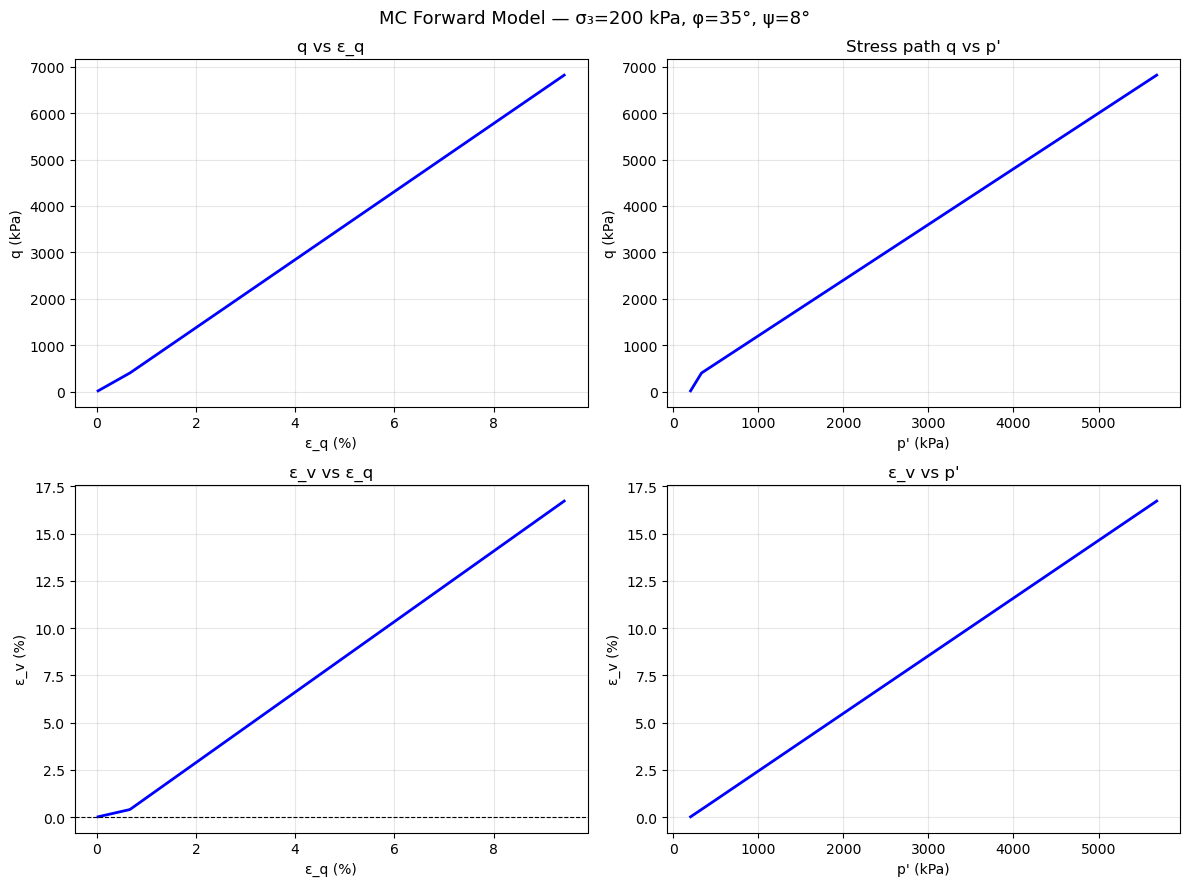

In [19]:
    E  = 50000 #kPa
    nu = 0.25
    K  = E / (3*(1 - 2*nu))
    G  = E / (2*(1 + nu))

    q, eps_q, eps_v, p = MC_forward(
        K,
        G,
        phi_deg = 30.0,
        psi_deg = 4.0,
        c       = 0.0,
        sigma3  = 200.0,
        eps_max = 0.15,
        n_steps = 500
    )

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0,0].plot(eps_q*100, q, 'b', lw=2)
    axes[0,0].set_xlabel('ε_q (%)') 
    axes[0,0].set_ylabel('q (kPa)')
    axes[0,0].set_title('q vs ε_q') 
    axes[0,0].grid(alpha=0.3)

    axes[0,1].plot(p, q, 'b', lw=2)
    axes[0,1].set_xlabel("p' (kPa)")
    axes[0,1].set_ylabel('q (kPa)')
    axes[0,1].set_title("Stress path q vs p'")
    axes[0,1].grid(alpha=0.3)

    axes[1,0].plot(eps_q*100, eps_v*100, 'b', lw=2)
    axes[1,0].set_xlabel('ε_q (%)')
    axes[1,0].set_ylabel('ε_v (%)')
    axes[1,0].set_title('ε_v vs ε_q')
    axes[1,0].grid(alpha=0.3)
    axes[1,0].axhline(0, color='k', lw=0.8, ls='--')

    axes[1,1].plot(p, eps_v*100, 'b', lw=2)
    axes[1,1].set_xlabel("p' (kPa)")
    axes[1,1].set_ylabel('ε_v (%)')
    axes[1,1].set_title("ε_v vs p'")
    axes[1,1].grid(alpha=0.3)

    plt.suptitle(f'MC Forward Model — σ₃=200 kPa, φ=35°, ψ=8°', fontsize=13)
    plt.tight_layout()
    plt.show()

## True Model

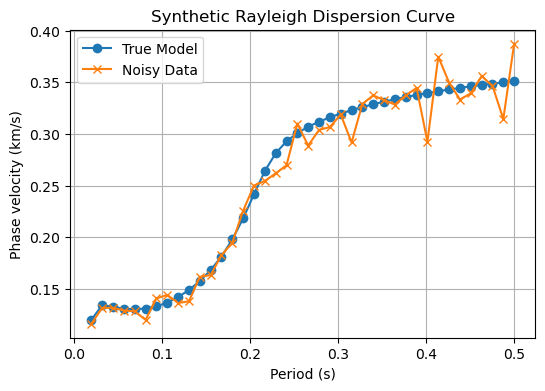

In [448]:
# units per disba documentation
# thickness (km)
thickness_true = [0.004, 0.002, 0.003, 0.005, 0.006, 0.0]  # km, sums to 25m
vs_true = [0.150, 0.100, 0.220, 0.185, 0.300, 0.420]
vp_true = [2*v for v in vs_true]
rho = [1.8]*6   
period = np.linspace(0.02, 0.5, 40)

truemodel = forward_model(thickness_true, vp_true, vs_true, rho, period)

dobs = truemodel.velocity
noise_level = 0.05
dobs_noisy= dobs + noise_level * dobs * np.random.randn(len(dobs))

T = truemodel.period

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (km/s)")
plt.title("Synthetic Rayleigh Dispersion Curve")
plt.grid(True)
plt.legend()
plt.savefig("outputs/figure1_dispersion.png", dpi=300, bbox_inches='tight')
plt.show()


In [421]:
def objective_function(beta, alpha_s, alpha_x, dpred, dobs, vs):

    phi_d = np.sum(((dpred - dobs))**2)
    phi_s = np.sum(np.array(vs)**2) 
    phi_x = np.sum(np.diff(vs)**2) # no division by layer thickness - layer thicknesses are constant and small. including it would blow up the smallness term, thus requiring a smaller alpha_x to balance out (no point)
    
    phi_m = alpha_s * phi_s + alpha_x * phi_x
    phi = phi_d + beta * phi_m
    
    return phi, phi_d, phi_m

## Steepest Descent / Gradient


In [422]:
def gradient_function(vs, thickness, rho, period, dobs, beta, alpha_s, alpha_x, dx=1e-4):
# Taking a small step (up and down) in a direction to determine gradient of objective function
    grad = [0.0] * len(vs)

    for i in range(len(vs)):
        vs_up = vs.copy()
        vs_up[i] += dx
        vs_down = vs.copy()
        vs_down[i] -= dx
        vs_now = vs.copy() # used for debugging
        vp_now = [2*v for v in vs_now] # used for debugging
        vp_up = [2*v for v in vs_up]
        vp_down = [2*v for v in vs_down]
        
        try:
            dpred_up = forward_model(thickness, vp_up, vs_up, rho, period).velocity
            phiup, _, _= objective_function(beta, alpha_s, alpha_x, dpred_up, dobs, vs_up)

            dpred_down = forward_model(thickness, vp_down, vs_down, rho, period).velocity
            phidown, _, _= objective_function(beta, alpha_s, alpha_x, dpred_down, dobs, vs_down)
            grad[i] = (phiup - phidown) / (2 * dx)
        except Exception:
            grad[i] = 0
    return grad

In [253]:
def step_function(grad_vs, step, vs):
    # function take a small step in the direction of the gradient to update vs
    # no negative swave velocities - minimum 50 m/s, max 800 m/s - set to stabilize shallow depths and half space
    vs_new = [0.0] * len(vs)
    for i in range(len(vs)):
        vs_new [i]= max(min(vs[i] - step * grad_vs[i], .8), 0.05)
    vp_new = [2*v for v in vs_new]
    return vs_new, vp_new

In [ ]:
thickness_first = [0.005, 0.005, 0.005, 0.005, 0.0]
vs_first = [0.05, 0.10, 0.15, 0.20, 0.25]
vp_first = [2*v for v in vs_first] # assume p-waves are 2x s-waves (generally true)
rho_first = [1.8]*5

In [273]:
print("phi_s:", np.sum(np.array(vs_first)**2))
print("phi_x:", np.sum(np.diff(vs_first)**2))
print("Thus, the alpha_s should be 1/10 of alpha_x to give them equal weight")

phi_s: 0.1375
phi_x: 0.01
Thus, the alpha_s should be 1/10 of alpha_x to give them equal weight


In [274]:
# while loop settings
beta_steep = 5 # regularization parameter - constant for now
alpha_s_steep = 0.05 
alpha_x_steep = 0.5

dpred_first = forward_model(thickness_first, vp_first, vs_first, rho_first, period).velocity
obj_first = objective_function(beta_steep, alpha_s_steep, alpha_x_steep, dpred_first, dobs_noisy, vs_first)


phi_first, phi_d_first, phi_m_first = objective_function(beta_steep, alpha_s_steep, alpha_x_steep, dpred_first, dobs_noisy, vs_first)

step0 = 1e-3
i = 0
max_iter = 500
vs_current = vs_first.copy()
phi_current = phi_first
phi_diff = 999
tol_phi = 1e-4
phi_history = []

while (phi_diff > tol_phi) and (i <= max_iter):
# halves the step until phi does not change much anymore (tol_phi)
    i += 1
    step = step0 # reset the step size at start of iteration
    n_half = 0 # reset step counter at start of iteration

    grad_current = gradient_function(vs_current, thickness_first, rho_first, period, dobs_noisy, beta_steep, alpha_s_steep, alpha_x_steep)

    while n_half < 20:
        vs_trial_new, vp_trial_new = step_function(grad_current, step, vs_current)
        try: # added to catch errors from forward model (e.g. vs is too low)
            dpred_new = forward_model(thickness_first, vp_trial_new, vs_trial_new, rho_first, period).velocity
            phi_new, phi_d_new, phi_m_new = objective_function(beta_steep, alpha_s_steep, alpha_x_steep, dpred_new, dobs_noisy, vs_trial_new)
        except Exception:
            step *= 0.5
            n_half += 1
            continue
    
        if phi_new < phi_current:
            #checks phi_new is smaller than phi_current and accepts changes if so
            phi_diff = abs(phi_new - phi_current)
            vs_current = vs_trial_new
            vp_current = vp_trial_new
            dpred_current = dpred_new
            phi_current = phi_new
            phi_history.append(phi_new)
            print(f"phi_diff={phi_diff:.3e}")
            break
        #phi_new > phi_current: spit the step and go again.
        step *= 0.5
        n_half += 1
    if n_half == 20:
        break

phi_diff=5.293e-01
phi_diff=7.508e-02
phi_diff=5.563e-02
phi_diff=4.479e-02
phi_diff=3.771e-02
phi_diff=3.267e-02
phi_diff=2.887e-02
phi_diff=2.587e-02
phi_diff=2.342e-02
phi_diff=2.137e-02
phi_diff=1.963e-02
phi_diff=1.811e-02
phi_diff=1.678e-02
phi_diff=1.559e-02
phi_diff=1.453e-02
phi_diff=1.357e-02
phi_diff=1.270e-02
phi_diff=1.189e-02
phi_diff=1.115e-02
phi_diff=1.047e-02
phi_diff=9.846e-03
phi_diff=9.257e-03
phi_diff=8.707e-03
phi_diff=8.202e-03
phi_diff=7.725e-03
phi_diff=7.278e-03
phi_diff=6.859e-03
phi_diff=6.467e-03
phi_diff=6.100e-03
phi_diff=5.749e-03
phi_diff=5.423e-03
phi_diff=5.117e-03
phi_diff=4.828e-03
phi_diff=4.555e-03
phi_diff=4.300e-03
phi_diff=4.058e-03
phi_diff=3.831e-03
phi_diff=3.617e-03
phi_diff=3.414e-03
phi_diff=3.221e-03
phi_diff=3.044e-03
phi_diff=2.874e-03
phi_diff=2.716e-03
phi_diff=2.564e-03
phi_diff=2.422e-03
phi_diff=2.288e-03
phi_diff=2.161e-03
phi_diff=2.043e-03
phi_diff=1.931e-03
phi_diff=1.825e-03
phi_diff=1.724e-03
phi_diff=1.631e-03
phi_diff=1.5

In [275]:
print(f"iterations: {i}")
print(f"final vs: {vs_current}")
print("phi_d:", phi_d_first)
print("beta*alpha_s*phi_s:", beta_steep * alpha_s_steep * np.sum(np.array(vs_first)**2))
print("beta*alpha_x*phi_x:", beta_steep * alpha_x_steep * np.sum(np.diff(vs_first)**2))

iterations: 118
final vs: [np.float64(0.1593738736106417), np.float64(0.1768649286638791), np.float64(0.21353816009164098), np.float64(0.268344863560326), np.float64(0.3785519136516209)]
phi_d: 1.2893724226396848
beta*alpha_s*phi_s: 0.034375
beta*alpha_x*phi_x: 0.025


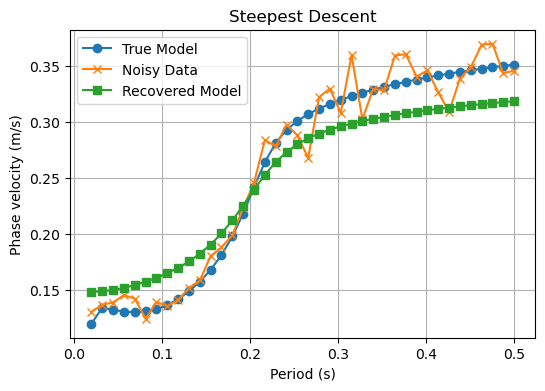

In [276]:
vs_final = vs_current.copy()
dpred_final = dpred_current.copy()

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.plot(T, dpred_final, marker="s", label="Recovered Model")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Steepest Descent")
plt.grid(True)
plt.legend()
plt.savefig("outputs/figure2_steepest_descent.png", dpi=300, bbox_inches='tight')
plt.show()

In [277]:
## Plotting Functions
def get_depth(thickness):
    depths = [0]
    for t in thickness[:-1]:
        depths.append(depths[-1] + t)
    depths.append(depths[-1] + thickness[-2])
    return depths

def step_Vsplot(vs, depth):
    vs_plot, depth_plot = [], []
    for i in range(len(vs)):
        vs_plot += [vs[i], vs[i]]
        depth_plot += [depth[i], depth[i+1]]
    return vs_plot, depth_plot

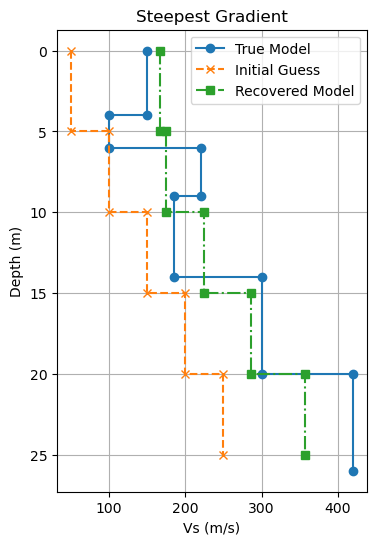

In [379]:
depth_true = get_depth(thickness_true)
depth_first = get_depth(thickness_first)

# stepped velocity profile
vs_true_plot, depth_true_plot = step_Vsplot(vs_true, depth_true)
vs_first_plot, depth_first_plot = step_Vsplot(vs_first, depth_first)
vs_final_plot, depth_final_plot = step_Vsplot(vs_final, depth_first)

# convert to meters (more common than km)
vs_true_plot = [v * 1000 for v in vs_true_plot]
vs_first_plot = [v * 1000 for v in vs_first_plot]
vs_final_plot = [v * 1000 for v in vs_final_plot]
depth_true_plot = [d * 1000 for d in depth_true_plot]
depth_first_plot = [d * 1000 for d in depth_first_plot]
depth_final_plot = [d * 1000 for d in depth_final_plot]

plt.figure(figsize=(4,6))
plt.plot(vs_true_plot, depth_true_plot, label="True Model", marker="o")
plt.plot(vs_first_plot, depth_first_plot, label="Initial Guess", ls="--", marker="x")
plt.plot(vs_final_plot, depth_final_plot, label="Recovered Model", ls="-.", marker="s")
plt.gca().invert_yaxis()
plt.xlabel("Vs (m/s)")
plt.ylabel("Depth (m)")
plt.title("Steepest Gradient")
plt.grid(True)
plt.legend()
plt.savefig("outputs/figure3_swave_steep_descent.png", dpi=300, bbox_inches='tight')
plt.show()


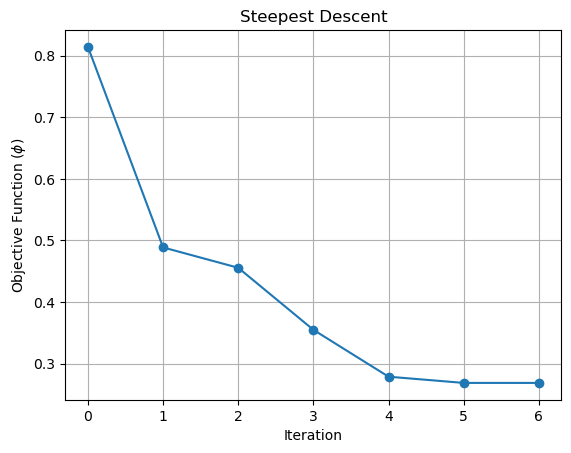

In [380]:
plt.plot(phi_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'Objective Function ($\phi$)')
plt.title('Steepest Descent')
plt.grid()
plt.savefig("outputs/figure4_convergence.png", dpi=300, bbox_inches='tight')
plt.show()

In [280]:
print(len(phi_history))

118


## Newton's Method

In [262]:
def hess_function(vs, thickness, rho, period, dobs, beta, alpha_s, alpha_x, dx=1e-4):
# Taylor Series approx for 2nd derivative: [ f(x+h) - 2f(x) + f(x-h) ] / h^2
    hess = [0.0] * len(vs)
    vp = [2*v for v in vs]

    for i in range(len(vs)):
        vs_up = vs.copy()
        vs_up[i] += dx
        vs_down = vs.copy()
        vs_down[i] -= dx
        vp_up = [2*v for v in vs_up]
        vp_down = [2*v for v in vs_down]
        try:    
            dpred_up = forward_model(thickness, vp_up, vs_up, rho, period).velocity
            phiup, _, _= objective_function(beta, alpha_s, alpha_x, dpred_up, dobs, vs_up)

            dpred_down = forward_model(thickness, vp_down, vs_down, rho, period).velocity
            phidown, _, _= objective_function(beta, alpha_s, alpha_x, dpred_down, dobs, vs_down)

            dpred_now = forward_model(thickness, vp, vs, rho, period).velocity
            phi, _, _ = objective_function(beta, alpha_s, alpha_x, dpred_now, dobs, vs)
            hess[i] = (phiup - 2*phi + phidown) / (dx**2)
        except Exception:
            hess[i] = 0.0
    return hess

In [263]:
def newton_inversion(beta, vs_init, thickness, rho, period, dobs, alpha_s, alpha_x,
                         max_iter=100, tol_phi=1e-4, tol_hess=1e-4):

    # initialize variables
    vp_newton_now = [2*v for v in vs_init]
    vs_newton_now = vs_init.copy()

    dpred_newton_now = forward_model(thickness, vp_newton_now, vs_newton_now, rho, period).velocity
    phi_newton_now, _, _ = objective_function(beta, alpha_s, alpha_x, dpred_newton_now, dobs, vs_newton_now)

    grad_newton = gradient_function(vs_newton_now, thickness, rho, period, dobs, beta, alpha_s, alpha_x)
    hess_newton = hess_function(vs_newton_now, thickness, rho, period, dobs, beta, alpha_s, alpha_x)

    phi_diff_newton = 9999
    phi_newton_history = []
    i = 0

    while (phi_diff_newton > tol_phi) and (i < max_iter):
        i += 1
        n_half = 0
        damping = 1.0 #reset at each iteration - damping used to halve the newton step

        step_newton = [-grad_newton[j] / hess_newton[j] if hess_newton[j] > tol_hess else 0.0
                       for j in range(len(vs_newton_now))]

        while n_half < 20:
            vs_newton_update = [max(vs_newton_now[j] + damping * step_newton[j], 0.01) for j in range(len(vs_newton_now))]
            vp_newton_update = [2*v for v in vs_newton_update]

            try: # added to catch errors from forward model (e.g. vs is too low)
                dpred_update = forward_model(thickness, vp_newton_update, vs_newton_update, rho, period).velocity
                phi_update, _, _ = objective_function(beta, alpha_s, alpha_x, dpred_update, dobs, vs_newton_update)
            except Exception:
                damping *= 0.5
                n_half += 1
                continue      

            if phi_update < phi_newton_now:
                phi_diff_newton = abs(phi_update - phi_newton_now)
                vs_newton_now = vs_newton_update
                vp_newton_now = vp_newton_update
                phi_newton_now = phi_update
                grad_newton = gradient_function(vs_newton_now, thickness, rho, period, dobs, beta, alpha_s, alpha_x)
                hess_newton = hess_function(vs_newton_now, thickness, rho, period, dobs, beta, alpha_s, alpha_x)
                phi_newton_history.append(phi_update)
                break
            damping *= 0.5
            n_half += 1

        if n_half == 20:
            break

    dpred_newton_final = forward_model(thickness, vp_newton_now, vs_newton_now, rho, period).velocity
    _, phi_d_newton_final, phi_m_newton_final = objective_function(beta, alpha_s, alpha_x, dpred_newton_final, dobs, vs_newton_now)


    return vs_newton_now, phi_d_newton_final, phi_m_newton_final, phi_newton_history

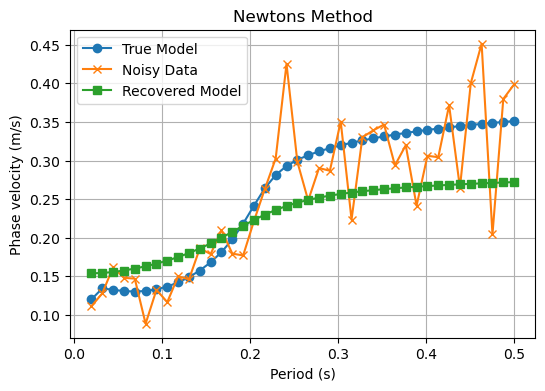

In [446]:
thickness_newton = [0.005, 0.005, 0.005, 0.005, 0.0]
vs_newton = [0.05, 0.10, 0.15, 0.20, 0.25]
vp_newton = [2*v for v in vs_newton]
rho_newton = [1.8]*5
beta_newton = 20

alpha_s_newton = 0.05
alpha_x_newton = 0.5

vs_newton_now, phi_d_newton_final, phi_m_newton_final, phi_newton_history = newton_inversion(beta_newton, vs_newton, thickness_newton, rho_newton, period, dobs_noisy, alpha_s_newton, alpha_x_newton)
vp_newton_now = [2*v for v in vs_newton_now]

dpred_newtonfinal = forward_model(thickness_newton, vp_newton_now, vs_newton_now, rho_newton, period).velocity

plt.figure(figsize=(6,4))
plt.plot(T, dobs, marker="o", label="True Model")
plt.plot(T, dobs_noisy, marker="x", label="Noisy Data")
plt.plot(T, dpred_newtonfinal, marker="s", label="Recovered Model")
plt.xlabel("Period (s)")
plt.ylabel("Phase velocity (m/s)")
plt.title("Newtons Method")
plt.grid(True)
plt.legend()
plt.savefig("outputs/figure7_newton.png", dpi=300, bbox_inches='tight')
plt.show()



In [447]:
print(beta_newton)
print("phi_total:", phi_d_newton_final + beta_newton * phi_m_newton_final)
print("phi_d:", phi_d_newton_final)
print("beta*phi_m:", beta_newton * phi_m_newton_final)
print("beta*alpha_s*phi_s:", beta_newton * alpha_s_newton * np.sum(np.array(vs_newton)**2))
print("beta*alpha_x*phi_x:", beta_newton * alpha_x_newton * np.sum(np.diff(vs_newton)**2))
print("ratio:", phi_d_newton_final / (beta_newton * phi_m_newton_final))

20
phi_total: 0.5303210177746065
phi_d: 0.1891875331392102
beta*phi_m: 0.3411334846353963
beta*alpha_s*phi_s: 0.1375
beta*alpha_x*phi_x: 0.1
ratio: 0.554585057346141


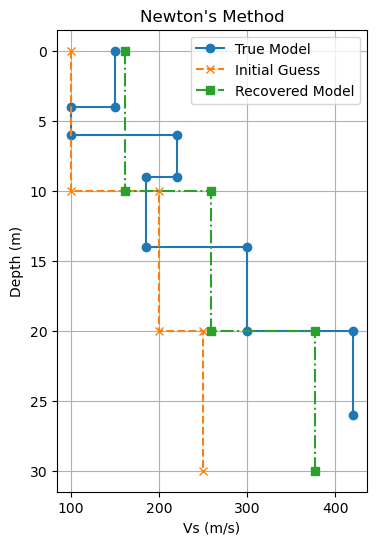

In [439]:
vs_true #true
vs_first #starting point
vs_newtonfinal = vs_newton_now.copy() #recovered

depth_true = get_depth(thickness_true)
depth_newtonfirst = get_depth(thickness_newton)

# stepped velocity profile
vs_true_plot, depth_true_plot = step_Vsplot(vs_true, depth_true)
vs_first_plot, depth_first_plot = step_Vsplot(vs_newton, depth_newtonfirst)
vs_newtonfinal_plot, depth_newtonfinal_plot = step_Vsplot(vs_newtonfinal, depth_newtonfirst)

# convert to meters (more common than km)
vs_true_plot = [v * 1000 for v in vs_true_plot]
vs_first_plot = [v * 1000 for v in vs_first_plot]
vs_newtonfinal_plot = [v * 1000 for v in vs_newtonfinal_plot]
depth_true_plot = [d * 1000 for d in depth_true_plot]
depth_first_plot = [d * 1000 for d in depth_first_plot]
depth_newtonfinal_plot = [d * 1000 for d in depth_newtonfinal_plot]

plt.figure(figsize=(4,6))
plt.plot(vs_true_plot, depth_true_plot, label="True Model", marker="o")
plt.plot(vs_first_plot, depth_first_plot, label="Initial Guess", ls="--", marker="x")
plt.plot(vs_newtonfinal_plot, depth_newtonfinal_plot, label="Recovered Model", ls="-.", marker="s")
plt.gca().invert_yaxis()
plt.xlabel("Vs (m/s)")
plt.ylabel("Depth (m)")
plt.title("Newton's Method")
plt.grid(True)
plt.legend()
plt.savefig("outputs/figure3_swave_newton.png", dpi=300, bbox_inches='tight')
plt.show()


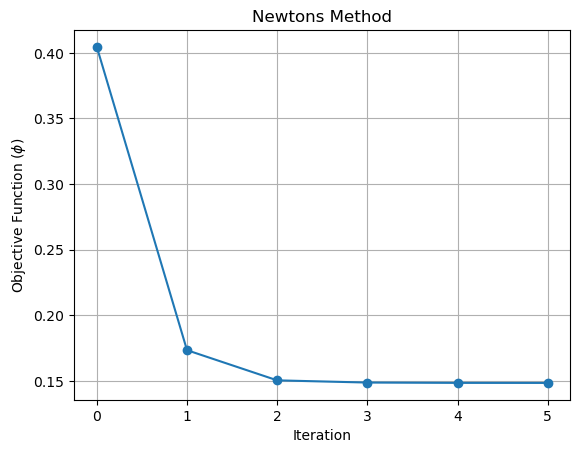

In [440]:
plt.plot(phi_newton_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'Objective Function ($\phi$)')
plt.title('Newtons Method')
plt.grid()
plt.savefig("outputs/figure4_convergence_newton.png", dpi=300, bbox_inches='tight')
plt.show()

In [441]:
def plot_tikhonov_curves(beta_values, phid, phim, n_periods, beta_index=0, ax=None, savepath=None): 
    if ax is None: 
        fig, ax = plt.subplots(1, 3, figsize=(12, 4)) 
    
    ax[0].semilogx(beta_values, phid)
    ax[1].semilogx(beta_values, phim)
    ax[2].loglog(phim, phid) 

    ax[0].semilogx(beta_values[beta_index], phid[beta_index], "ro")
    ax[1].semilogx(beta_values[beta_index], phim[beta_index], "ro")
    ax[2].loglog(phim[beta_index], phid[beta_index], "ro")
    
    ax[0].set_ylabel("$\\phi_d$")
    ax[1].set_ylabel("$\\phi_m$")
    ax[2].set_xlabel("$\\phi_m$")
    ax[2].set_ylabel("$\\phi_d$")
   
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

In [268]:
def plot_inversion_results(vs_true, vs_first, vs_finals, thickness_true, thickness_inv, dobs, dpreds, phi_histories, beta_index=0, ax=None, savepath=None):
    if ax is None: 
        fig, ax = plt.subplots(1, 3, figsize=(12, 3)) 

    depth_true = get_depth(thickness_true)
    depth_inv = get_depth(thickness_inv)

    #plot 1: Vs profile
    vs_true_plot, depth_true_plot = step_Vsplot(vs_true, depth_true)
    vs_rec_plot, depth_rec_plot = step_Vsplot(vs_finals[beta_index], depth_inv)
    vs_first_plot, depth_first_plot = step_Vsplot(vs_first, depth_inv)

    ax[0].plot([v*1000 for v in vs_true_plot], [d*1000 for d in depth_true_plot], label="true")
    ax[0].plot([v*1000 for v in vs_first_plot], [d*1000 for d in depth_first_plot], ls="--", label="initial")
    ax[0].plot([v*1000 for v in vs_rec_plot], [d*1000 for d in depth_rec_plot], ls="-.", label="recovered")
    ax[0].invert_yaxis()
    ax[0].set_xlabel("Vs (m/s)")
    ax[0].set_ylabel("Depth (m)")
    ax[0].legend()

    # plot 2: observed vs predicted data
    ax[1].plot(dobs, "o", label="observed")
    ax[1].plot(dpreds[beta_index], "-s", label="predicted")
    ax[1].set_xlabel("Period index")
    ax[1].set_ylabel("Phase velocity (km/s)")
    ax[1].legend()

    # plot 3: convergence history at selected beta
    ax[2].plot(phi_histories[beta_index], "o-")
    ax[2].set_xlabel("Iteration")
    ax[2].set_ylabel("$\\phi$")
    ax[2].set_title("Convergence")
    ax[2].grid(True)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

In [323]:
betas = np.logspace(-2, 1, 20)
phi_d_vals = np.zeros(len(betas))
phi_m_vals = np.zeros(len(betas))
vs_finals = []
dpreds = []
phi_histories = []  # add this

for i, beta in enumerate(betas):
    vs_final, phi_d, phi_m, phi_history = newton_inversion(
        beta, vs_newton, thickness_newton, rho_newton, period, dobs_noisy, alpha_s_newton, alpha_x_newton)
    phi_d_vals[i] = phi_d
    phi_m_vals[i] = phi_m
    vs_finals.append(vs_final)
    dpreds.append(forward_model(thickness_newton, [2*v for v in vs_final], vs_final, rho_newton, period).velocity)
    phi_histories.append(phi_history)

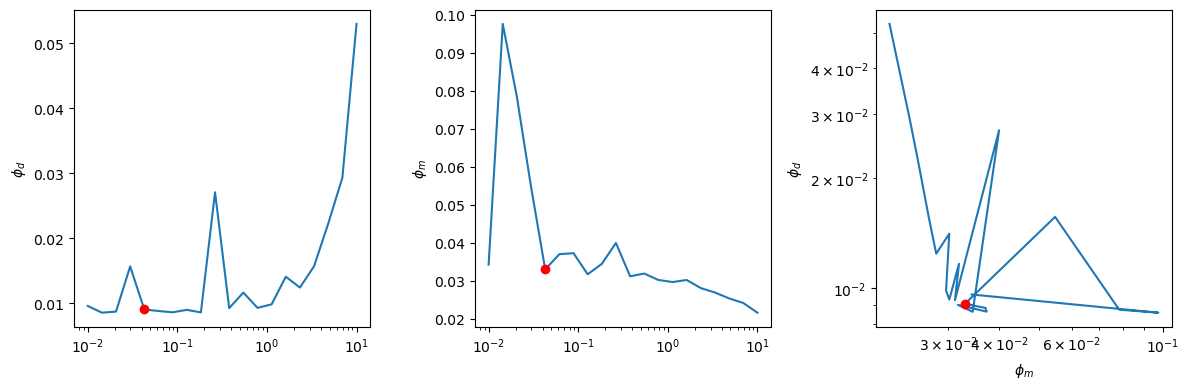

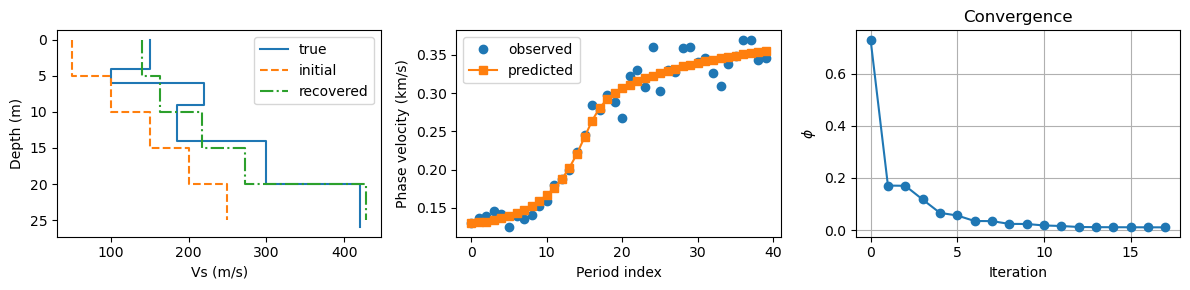

In [ ]:
plot_index = 4
plot_tikhonov_curves(betas, phi_d_vals, phi_m_vals, len(period), beta_index=plot_index, ax=None, savepath="outputs/figure5_tikhonov_newton.png")
plot_inversion_results(vs_true, vs_first, vs_finals, thickness_true, thickness_newton, dobs_noisy, dpreds, phi_histories, beta_index=plot_index, ax=None, savepath="outputs/figure8_inversion_newton.png")

In [290]:
i=4
print(betas[i])
print("phi_total:", phi_d_vals[i] + betas[i] * phi_m_vals[i])
print("phi_d:", phi_d_vals[i])
print("phi_m:", phi_m_vals[i])
print("beta*alpha_s*phi_s:", betas[i] * alpha_s_newton * np.sum(np.array(vs_finals[i])**2))
print("beta*alpha_x*phi_x:", betas[i] * alpha_x_newton * np.sum(np.diff(vs_finals[i])**2))

0.04281332398719394
phi_total: 0.010475142145001509
phi_d: 0.009063581621992889
phi_m: 0.032970122185113165
beta*alpha_s*phi_s: 0.0007536989016918664
beta*alpha_x*phi_x: 0.000657861621316754
